In [3]:
# Импорты необходимых для работы библиотек
import os
import shutil
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

# Загрузка датасета

In [2]:
# скрипт для загрузки архива датасета с сайта по ссылке
!wget "https://zenodo.org/record/8387071/files/DeepSpaceYoloDataset.zip?download=1" -O DeepSpaceYoloDataset.zip

--2025-03-25 11:50:44--  https://zenodo.org/record/8387071/files/DeepSpaceYoloDataset.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.43.25, 188.185.45.92, 188.185.48.194, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/8387071/files/DeepSpaceYoloDataset.zip [following]
--2025-03-25 11:50:46--  https://zenodo.org/records/8387071/files/DeepSpaceYoloDataset.zip
Connecting to zenodo.org (zenodo.org)|188.185.43.25|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1144480079 (1.1G) [application/octet-stream]
Saving to: ‘DeepSpaceYoloDataset.zip’

DeepSpaceYoloDatase 100%[===================>]   1.07G  19.3MB/s    in 60s     

2025-03-25 11:51:48 (18.2 MB/s) - ‘DeepSpaceYoloDataset.zip’ saved [1144480079/1144480079]



In [3]:
# Разархивируем архив
!unzip DeepSpaceYoloDataset.zip -d Dataset

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: Dataset/DeepSpaceYoloDataset/images/726.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/727.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/728.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/729.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/73.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/730.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/731.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/732.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/733.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/734.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/735.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/736.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/737.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/738.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images/739.jpg  
  inflating: Dataset/DeepSpaceYoloDataset/images

# Анализ Датасета

**Датасет размещен в разделе _Файлы_ Colab'а.**

### Структура датасета

<pre>
DeepSpaceYoloDataset/
├── images/
│   ├── example.jpg
│   └── ...
└── labels/
    ├── example.txt
    └── ...
</pre>

- **images**: содержит изображения.
- **labels**: содержит файлы аннотаций с bounding boxes для каждого изображения.

> **Примечание:** Имена файлов в обеих папках совпадают и являются id соответствующего фото.


## Посмотрим данные глазами

### Формат боксов в YOLO

В файлах аннотаций для YOLO каждая строка описывает один bounding box в формате:

<class> <x_center> <y_center> <width> <height>


- **<class>**: целое число, обозначающее класс объекта.
- **<x_center>**: координата центра бокса по оси X, нормированная (значение от 0 до 1).
- **<y_center>**: координата центра бокса по оси Y, нормированная (значение от 0 до 1).
- **<width>**: ширина бокса, нормированная относительно ширины изображения.
- **<height>**: высота бокса, нормированная относительно высоты изображения.

_Пример строки:_  

2 0.5 0.5 0.2 0.3

Это означает, что объект класса `2` расположен в центре изображения, его ширина составляет 20% от ширины изображения, а высота – 30%.


Each RGB image has a resolution of 608 × 608 pixels and corresponds to the capture of different zones of the night sky visible in Northern Hemisphere.

### Выведем фото и разметку на нем

In [1]:
# Путь к корневой папке датасета
dataset_path = './Dataset/'
# Пути к папкам с изображениями и аннотациями
images_dir = dataset_path + 'DeepSpaceYoloDataset/images/'
labels_dir = dataset_path + 'DeepSpaceYoloDataset/labels/'


Содержимое файла разметки:
0 0.8026315789473685 0.709703947368421 0.06907894736842106 0.07730263157894737
0 0.9925986842105263 0.44243421052631576 0.014802631578947368 0.039473684210526314



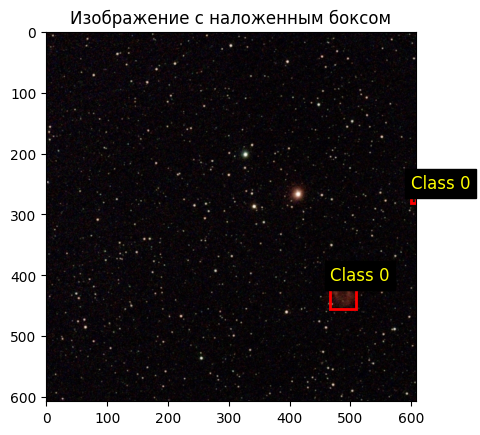

In [4]:
# Имя файла изображения и соответствующего файла разметки
# ПОТЫКАЙТЕ РАЗНЫЕ НАЗВАНИЯ ФАЙЛОВ, ЧТОБЫ ПОСМОТРЕТЬ РАЗНЫЕ ФОТО
image_filename = images_dir + '1.jpg'
annotation_filename = labels_dir + '1.txt'

# Выведем содержимое файла разметки:
print("\nСодержимое файла разметки:")
with open(annotation_filename, 'r') as f:
    annotations_text = f.read()
    print(annotations_text)

# Загрузим изображение с помощью PIL:
image = Image.open(image_filename)
img_width, img_height = image.size

# Парсинг файла аннотации
boxes = []
with open(annotation_filename, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) != 5:
            continue  # Пропускаем некорректные строки
        cls, x_center, y_center, w, h = map(float, parts)
        # Переводим нормализованные значения в абсолютные пиксели:
        x_center *= img_width
        y_center *= img_height
        w *= img_width
        h *= img_height
        # Вычисляем координаты верхнего левого угла
        x1 = x_center - w / 2
        y1 = y_center - h / 2
        boxes.append((int(x1), int(y1), int(w), int(h), int(cls)))

# Визуализируем изображение и накладываем прямоугольники:
fig, ax = plt.subplots(1)
ax.imshow(image)

for (x1, y1, w, h, cls) in boxes:
    # Рисуем прямоугольник (bbox) на изображении
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    # Выводим метку класса рядом с прямоугольником
    ax.text(x1, y1, f'Class {cls}', color='yellow', fontsize=12, backgroundcolor='black')

plt.title("Изображение с наложенным боксом")
plt.show()

## Посмотрим статистические данные о нашем датасете

Нам интересно узнать:
- **Сколько у нас вообще фото**
- **Сколько из них размечено**
- **Сколько фото размечены некорректно**

> **Результат:**  
> Этот датасет околоидеальный, поэтому все файлы размечены корректно, и некорректных аннотаций нет.


In [5]:
# Получаем список файлов изображений (расширения jpg, jpeg, png)
image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg'))]
total_images = len(image_files)

annotated_count = 0
empty_annotations_count = 0
invalid_annotations = []  # для хранения файлов с некорректными аннотациями

# Проходим по каждому изображению и проверяем соответствующий файл разметки
for img_file in image_files:
    # Получаем базовое имя файла (без расширения)
    base_name = os.path.splitext(img_file)[0]
    label_file = os.path.join(labels_dir, base_name + '.txt')

    # Проверяем, существует ли файл аннотации
    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            lines = f.readlines()

        # Если файл пустой, считаем аннотацию пустой
        if len(lines) == 0:
            empty_annotations_count += 1
        else:
            valid = True
            # Проверяем каждую строку аннотации
            for line in lines:
                tokens = line.strip().split()
                # Формат: <class> <x_center> <y_center> <width> <height>
                if len(tokens) != 5:
                    valid = False
                    break
                # Проверяем, что все значения можно привести к float
                try:
                    _ = list(map(float, tokens))
                except ValueError:
                    valid = False
                    break
            if valid:
                annotated_count += 1
            else:
                invalid_annotations.append(label_file)
    else:
        # Если файла аннотации нет, считаем его пустым
        empty_annotations_count += 1

print("Общее количество изображений:", total_images)
print("Количество изображений с корректной аннотацией:", annotated_count)
print("Количество изображений без аннотаций или с пустыми файлами:", empty_annotations_count)


Общее количество изображений: 4696
Количество изображений с корректной аннотацией: 4696
Количество изображений без аннотаций или с пустыми файлами: 0


# Подготовка датасета к обучению




Теперь сделаем главное:
- Разделим датасет на обучающую/валидационную/тестовую выборки

In [6]:
# Пути для сохранения разделённых данных
output_dir = dataset_path + "DeepSpaceYoloDataset_splited/"
train_images_dir = output_dir + "train/images/"
train_labels_dir =output_dir + "train/labels/"
val_images_dir = output_dir + "val/images/"
val_labels_dir = output_dir + "val/labels/"
test_images_dir = output_dir + "test/images/"
test_labels_dir = output_dir + "test/labels/"

In [7]:
# Получаем список всех файлов изображений
image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg'))]
image_files.sort()

# Создаем все необходимые директории, включая поддиректории
directories = [
    train_images_dir, train_labels_dir,
    val_images_dir, val_labels_dir,
    test_images_dir, test_labels_dir
]
for directory in directories:
    os.makedirs(directory, exist_ok=True)

# Разделяем файлы:
# Сначала на train (75%) и val+test (25%)
train_files, val_test_files = train_test_split(image_files, test_size=0.25, random_state=42)
# Затем из val+test выделяем валидацию(35%)
val_files, test_files = train_test_split(val_test_files, test_size=0.65, random_state=42)

print("Общее количество изображений:", len(image_files))
print("Количество изображений для обучения:", len(train_files))
print("Количество изображений для валидации:", len(val_files))
print("Количество изображений для тестирования:", len(test_files))

def copy_files(file_list, src_images, src_labels, dst_images, dst_labels):
    for file in tqdm(file_list, desc="Копирование файлов"):
        base = os.path.splitext(file)[0]
        # Копируем изображение
        shutil.copy2(os.path.join(src_images, file), os.path.join(dst_images, file))
        # Копируем соответствующий файл аннотации, если он существует
        label_file = base + ".txt"
        src_label_path = os.path.join(src_labels, label_file)
        if os.path.exists(src_label_path):
            shutil.copy2(src_label_path, os.path.join(dst_labels, label_file))

# Копируем файлы для каждого набора
copy_files(train_files, images_dir, labels_dir, train_images_dir, train_labels_dir)
copy_files(val_files, images_dir, labels_dir, val_images_dir, val_labels_dir)
copy_files(test_files, images_dir, labels_dir, test_images_dir, test_labels_dir)

Общее количество изображений: 4696
Количество изображений для обучения: 3522
Количество изображений для валидации: 410
Количество изображений для тестирования: 764


Копирование файлов: 100%|██████████| 764/764 [00:01<00:00, 476.45it/s]


# Обучение модели

## Определение конфигов и гиперпараметров

Модель YOLOv8 из ultralytics требует конфигурационного файла с путями к разным выборкам и описанием кол-ва и названий классов. Она использует его для инициализации внутри себя объектов Dataset и Dataloader, которые уже будут использоваться в процессе обучения.

In [9]:
# Определяем содержимое файла data.yaml в виде многострочной строки
data_yaml_content = """
train: /content/Dataset/DeepSpaceYoloDataset_splited/train/images
val:   /content/Dataset/DeepSpaceYoloDataset_splited/val/images
test:  /content/Dataset/DeepSpaceYoloDataset_splited/test/images

nc: 1
names: ['object']
"""

# Записываем содержимое в файл data.yaml
with open("data.yaml", "w") as file:
    file.write(data_yaml_content.strip())

print("Файл data.yaml успешно создан!")

Файл data.yaml успешно создан!


Теперь создадим словарь с гиперпараметрами процесса обучения модели. Затем мы передадим его модели.

In [10]:
hyperparameters = {
'lr0': 0.01,           # начальная скорость обучения
'momentum': 0.937,     # моментум
'weight_decay': 0.0005,   # коэффициент регуляризации (L2)
'warmup_epochs': 3.0,   # количество эпох разминки
'warmup_momentum': 0.8,   # моментум в фазе разминки
'warmup_bias_lr': 0.1,  # скорость обучения для bias в фазе разминки
'box': 7.5,            # коэффициент потерь для регрессии координат боксов
'cls': 0.5,            # коэффициент потерь для классификации
'label_smoothing': 0.0  # сглаживание меток
}

## Реализация обучения

Для обучения используем реализацию YOLOv8 от ultralytics. Они предоставляют собственный фреймворк обучения, который скрывает под капотом реализацию многих процессов обучения, в нашей цели, попробовать обучить большую реальную модель сгодится.

In [11]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.8/949.8 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

## Ultralytics и модели семейства YOLOv8

Ultralytics сразу предоставляет файлы всех моделей из семейства YOLOv8.  
Эти файлы содержат описание архитектуры модели (какие слои с какими параметрами следуют друг за другом) и предобученные на датасетах с общими классами (яблоко, машина, дерево) веса для всех слоев модели.

---

Мы как раз соберем нашу модель с помощью `model = YOLO("yolov8n.pt")`.  
После успешной сборки модель отобразит в выводе получившуюся архитектуру.

---

Затем запустится цикл обучения. В этом фреймворке цикл обучения реализуется через вызов метода `.train()`.  
Все необходимые параметры и гиперпараметры мы передаем как аргументы для метода `.train()`. После успешной инициализации цикла обучения принятые гиперпараметры также будут выведены.

---

Также для повышения разнообразия данных, борьбы с переобучением у огромной, сложной модели мы используем метод аугментации данных. С гиперпараметрами аугментации данных также можно поиграться, чтобы получить лучшие результаты.

---

После каждой эпохи запускается инференс валидации

---

После окончания обучения можно сразу переходить к анализу результатов.


In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    task='detect',
    data="data.yaml",   # Файл с описанием датасета
    epochs=31,          # Количество эпох обучения
    imgsz=608,          # Размер изображений для обучения
    batch=32,           # Размер батча
    **hyperparameters,  # используем распаковку словаря, чтобы задать гиперпараметры
    device=0 if torch.cuda.is_available() else 'cpu'  ,          # Явно указываем использовать первый GPU (если доступно)

    # Параметры аугментации изображений
    fliplr=0.5,         # Вероятность горизонтального отражения
    flipud=0.0,         # Вероятность вертикального отражения
    hsv_h=0.015,        # Изменение оттенка (Hue)
    hsv_s=0.7,          # Изменение насыщенности (Saturation)
    hsv_v=0.4,          # Изменение яркости (Value)
    degrees=0.0,        # Максимальный угол поворота
    translate=0.1,      # Диапазон сдвига изображения
    scale=0.5,          # Диапазон масштабирования
    shear=0.0,          # Диапазон сдвига (shear)
    perspective=0.0     # Перспективное преобразование
    )

# После завершения обучения можно проверить результаты
print("Результаты обучения:")
print(results)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
Ultralytics 8.3.96 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=data.yaml, epochs=1, time=None, patience=100, batch=32, imgsz=608, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, s

train: Scanning /content/Dataset/DeepSpaceYoloDataset_splited/train/labels... 3522 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3522/3522 [00:02<00:00, 1217.98it/s]


train: New cache created: /content/Dataset/DeepSpaceYoloDataset_splited/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /content/Dataset/DeepSpaceYoloDataset_splited/val/labels... 410 images, 0 backgrounds, 0 corrupt: 100%|██████████| 410/410 [00:00<00:00, 443.55it/s]

val: New cache created: /content/Dataset/DeepSpaceYoloDataset_splited/val/labels.cache


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 608 train, 608 val
Using 2 dataloader workers
Logging results to runs/detect/train
Starting training for 1 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        1/1      3.56G      1.527      2.641       1.66          6        608: 100%|██████████| 111/111 [01:07<00:00,  1.64it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:10<00:00,  1.51s/it]


                   all        410        531      0.192      0.196     0.0905     0.0326

1 epochs completed in 0.024 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.2MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.96 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:07<00:00,  1.14s/it]


                   all        410        531      0.195      0.196     0.0913     0.0332
Speed: 0.3ms preprocess, 2.4ms inference, 0.0ms loss, 5.9ms postprocess per image
Results saved to runs/detect/train
Результаты обучения:
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x78c64a2bd990>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,  

# Просмотр результатов обучения

- **Сохранение экспериментов:**  
  Результаты всех экспериментов в этом фреймворке сохраняются в каталог `/runs/`, в котором идет разделение на решаемые задачи, в нашем случае `/detect/`, в котором уже хранятся поименованные эксперименты. По умолчанию они называются `train`(соответственно далее `train2`, `train3 ...).

- **Хранение результатов обучения:**  
  Все результаты каждого обучения хранятся в соответствующей папке. Там можно найти фото с наложенными боксами, скаляры и графики.

- **Генерация метрик:**  
  Данный фреймворк "из коробки" автоматически генерирует и сохраняет матрицу ошибок и скалярные метрики итогов обучения. Так как у нас всего один класс, матрица крайне удобна для чтения.


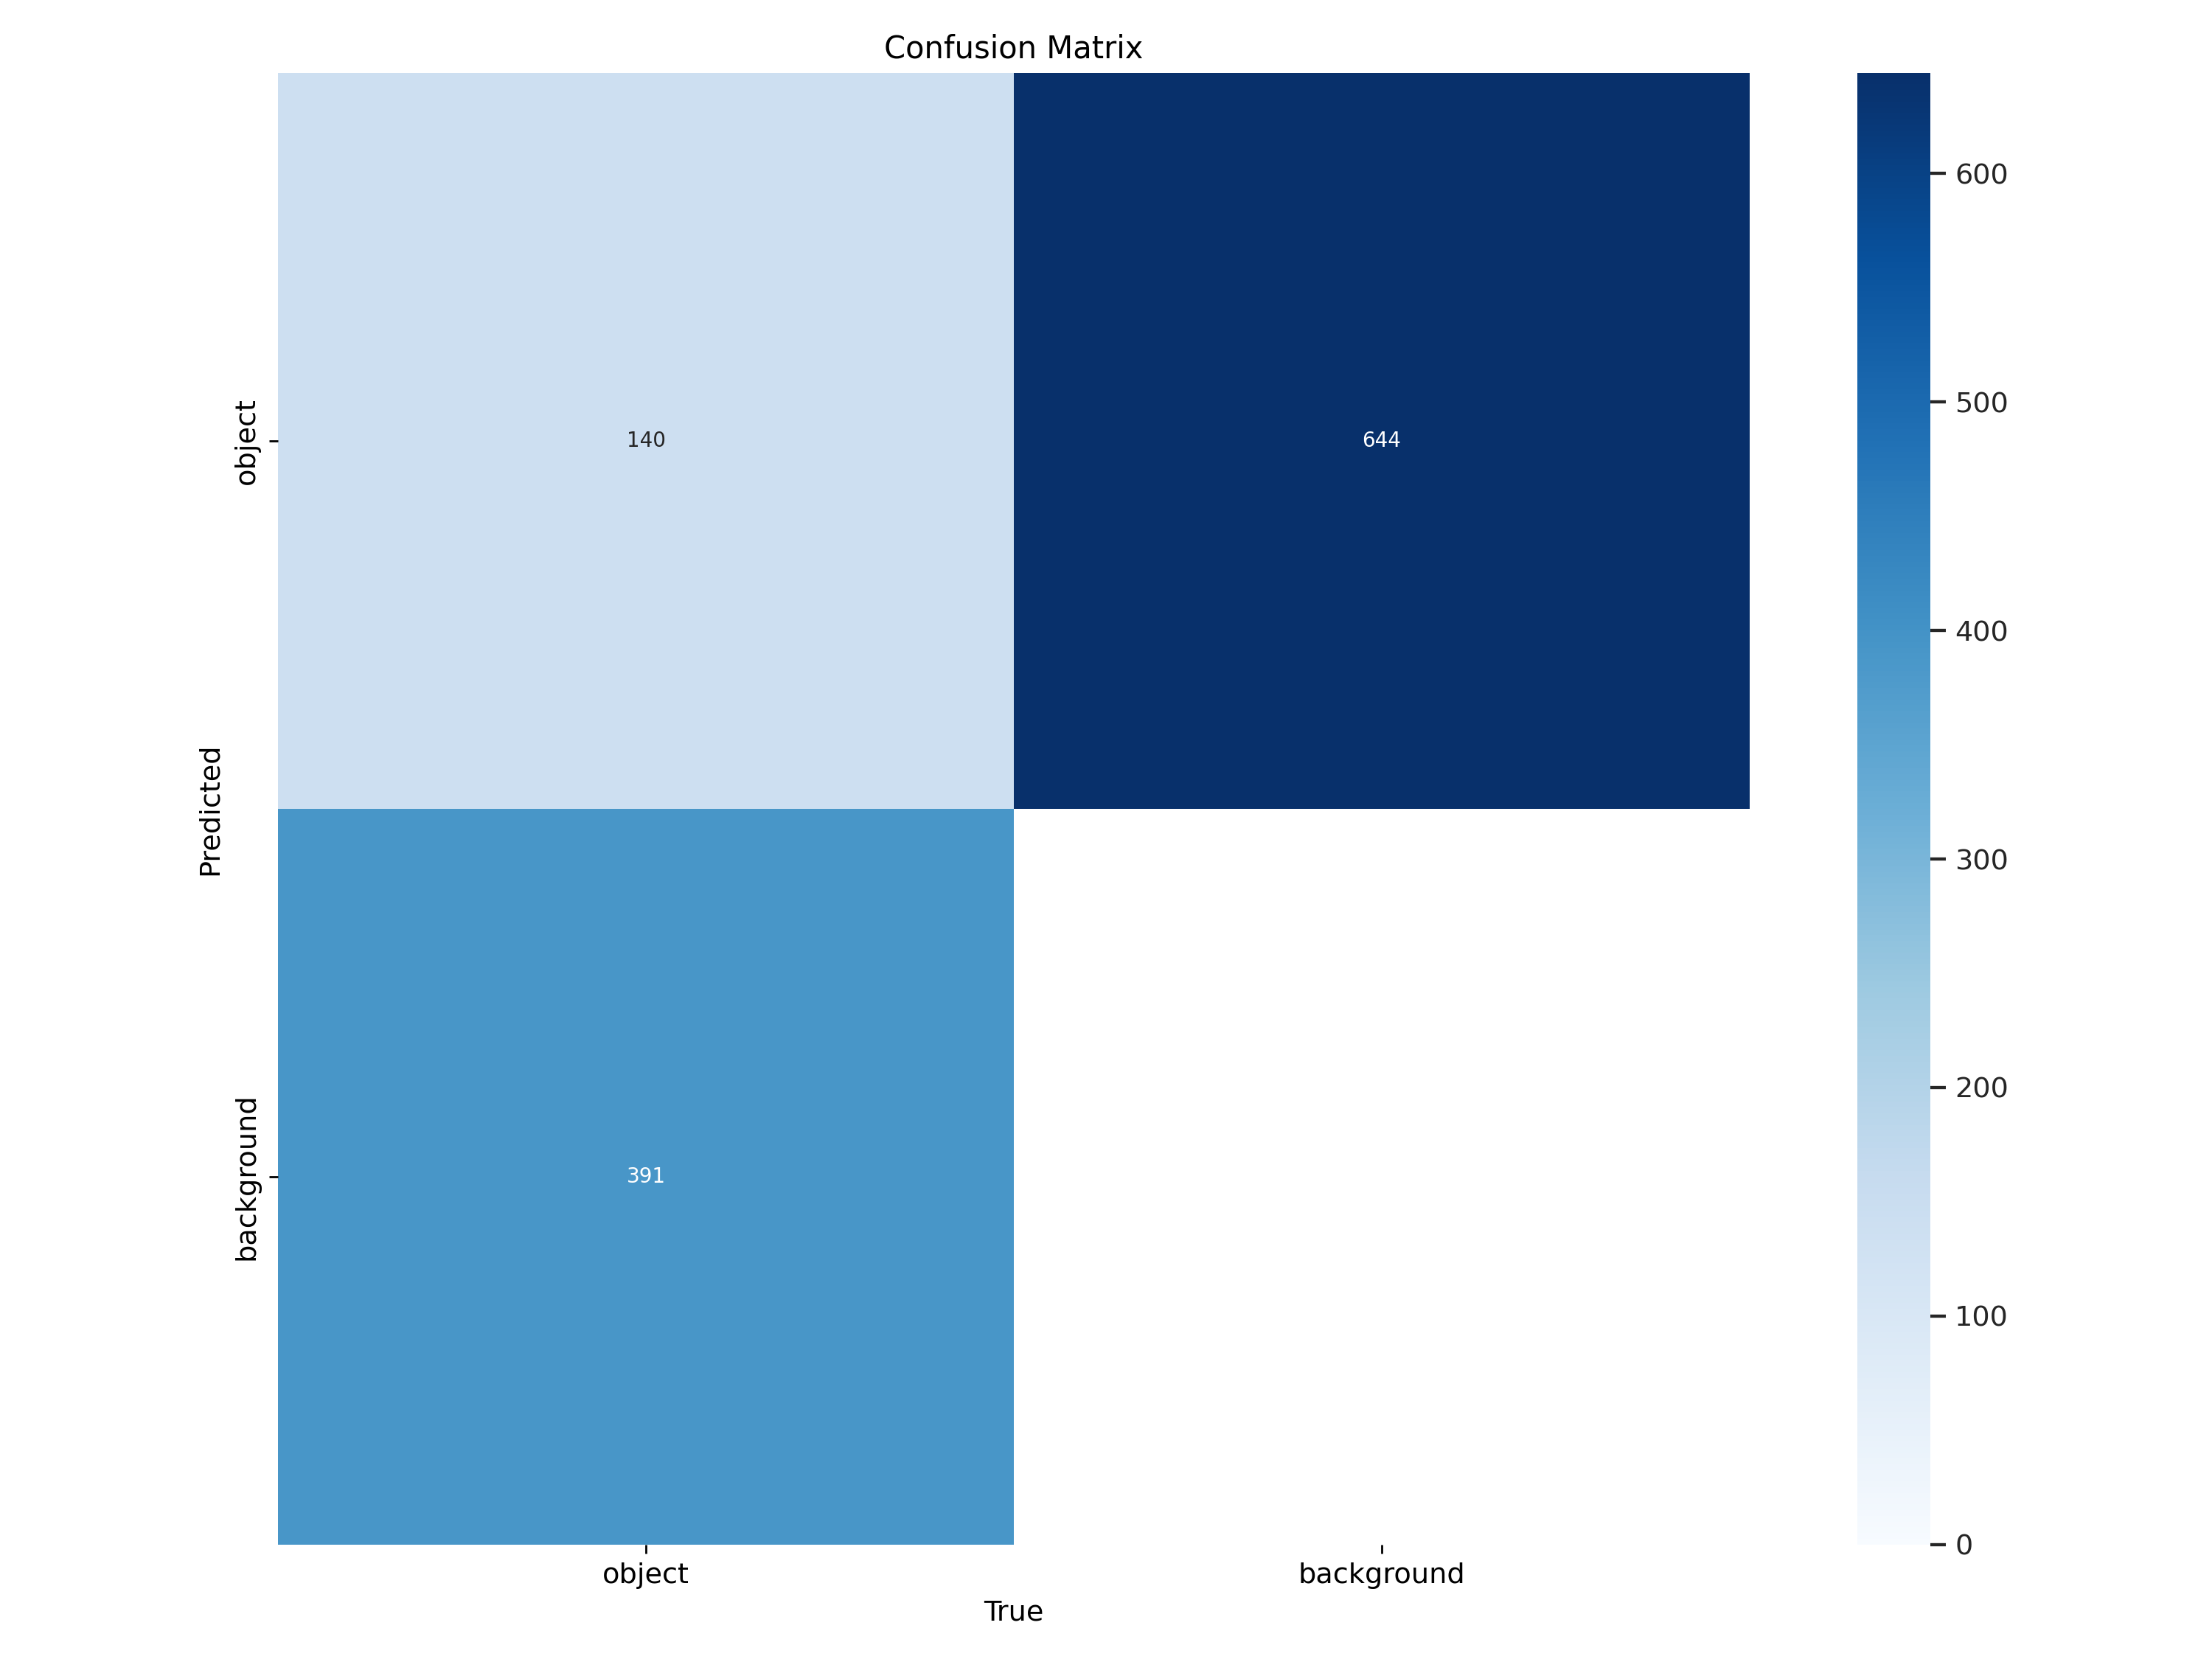

In [14]:
confusion_matrix = '/content/runs/detect/train/confusion_matrix.png'
img = Image.open(confusion_matrix)
img

В фреймворки Ultralytics YOLO метрики `(results/metrics)` отражают показатели, рассчитанные на валидационной выборке `(valid)`. Соответственно строя и проверяя свои гипотезы, в основном, вы должны преследовать цель улучшения метрики `(results/metrics/mAP50)`, так как это главная метрика в задаче детекции.

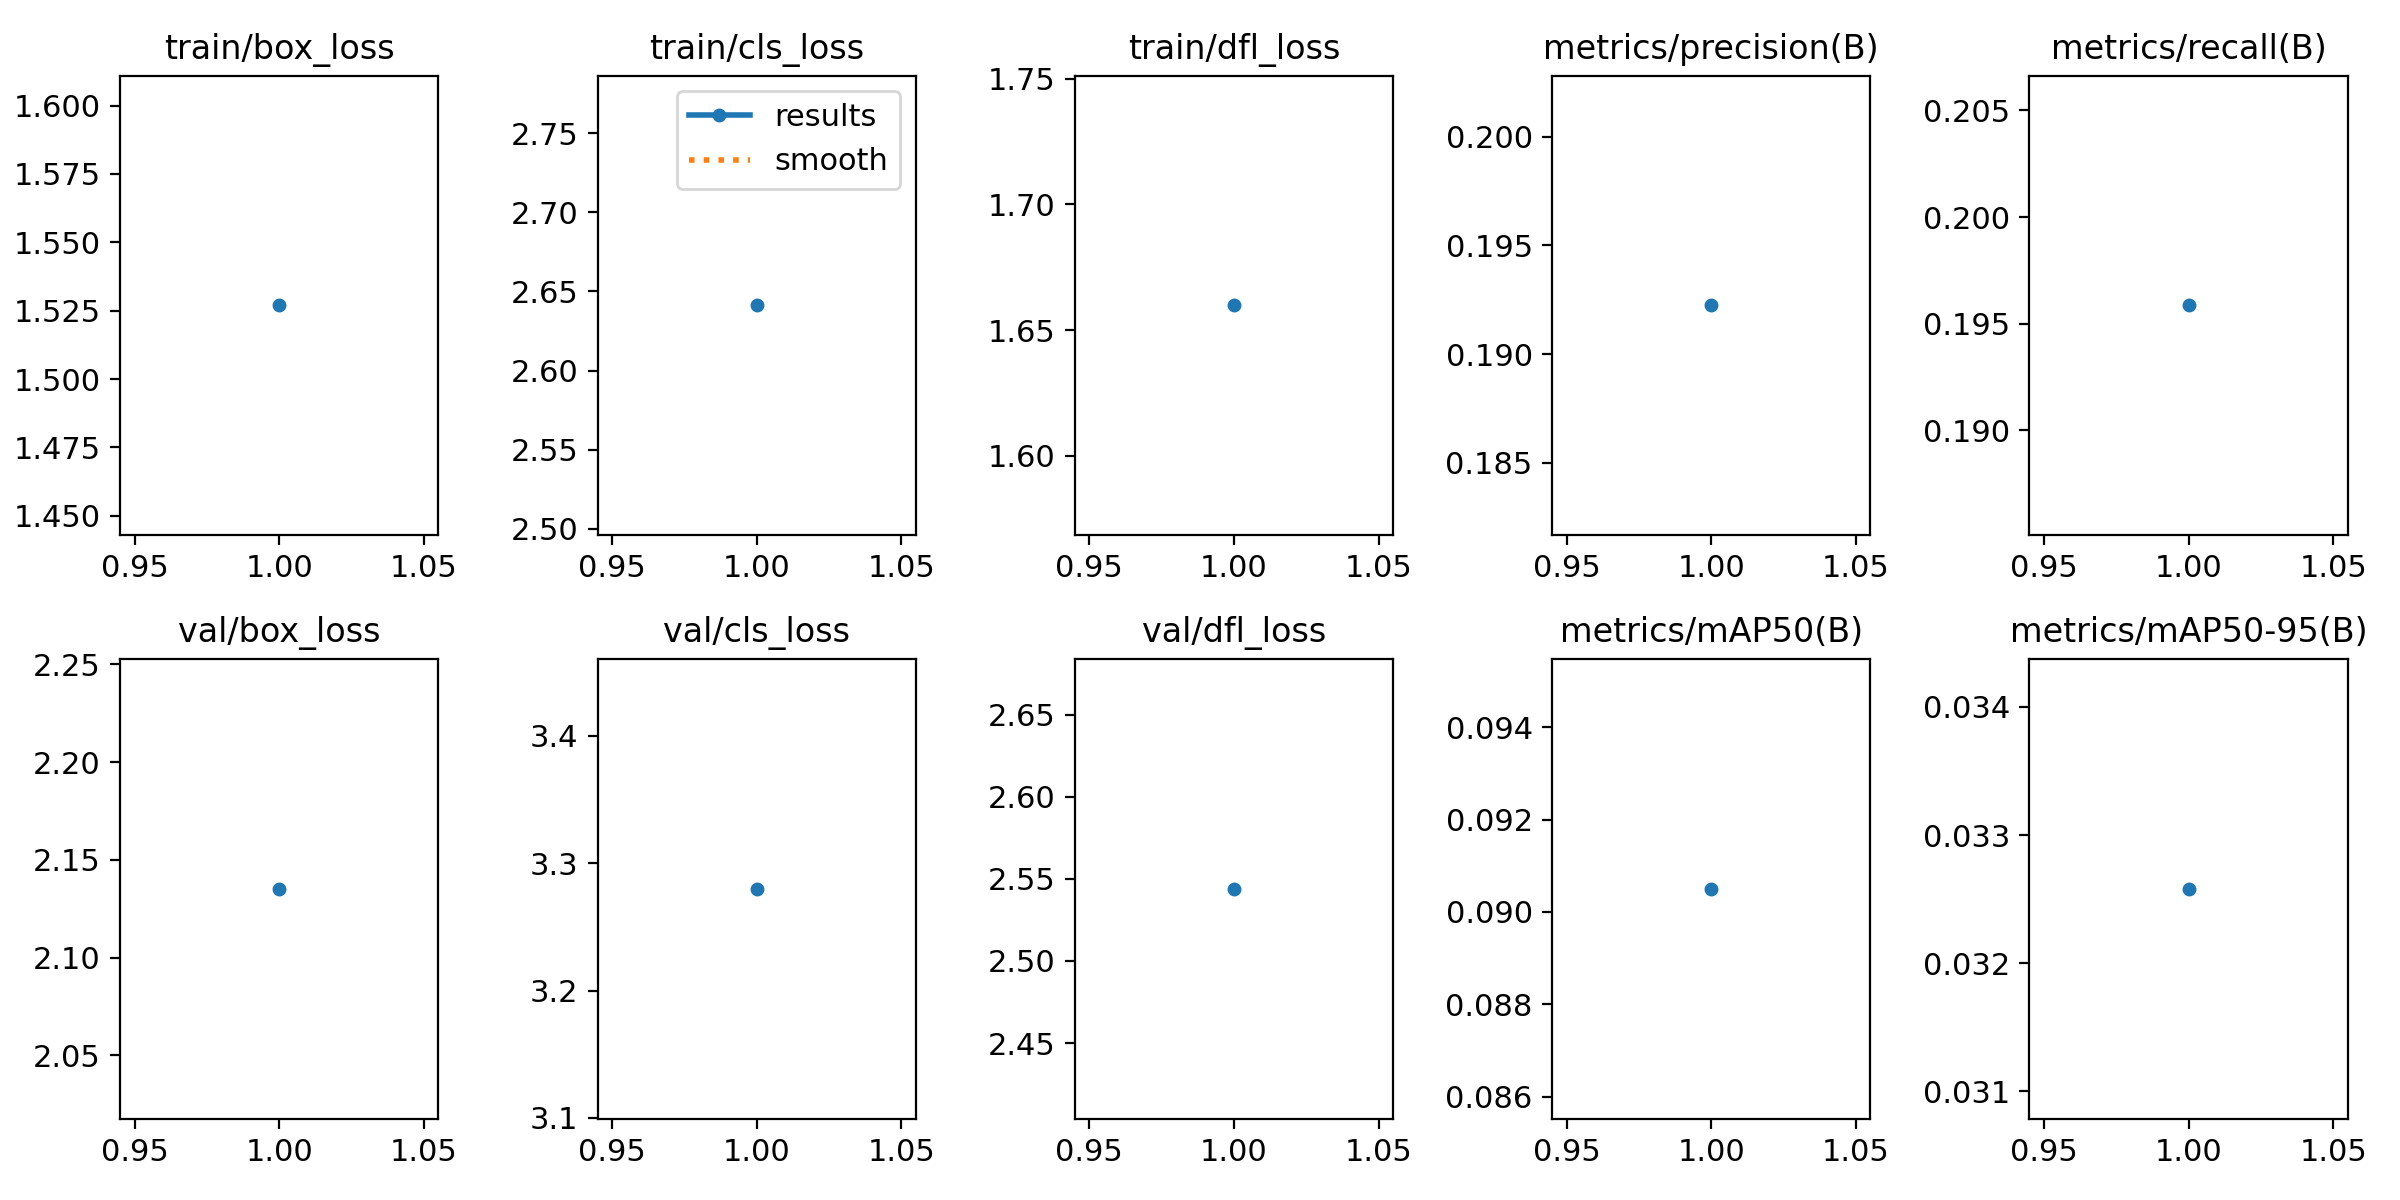

In [15]:
results_img = "/content/runs/detect/train/results.png"
img = Image.open(results_img)
img

Удобнейшим инструментом для просмотра результатов экспериментов является `TensorBoard`. В нем сбоку во вкладке `Time Series` можно выбрать эксперименты для сравнения и посмотреть все логгируемые метрики

In [ ]:
%load_ext tensorboard
%tensorboard --logdir /content/runs/detect/

# Проверка модели на отложенной тестовой выборке

Также, для запуска инференса модели (в т.ч. на тестовой выборке) в этом фреймворке существует метод `model.predict()`.

Для тестирования мы возьмем лучший чекпоинт(состояние весов модели в ходе обучение), который автоматически сохраняется как `best.pt`.

Загрузим из него модель и запустим инференс на тестовых данных.


In [22]:
test_model =  YOLO("/content/runs/detect/train/weights/best.pt")

model.predict("/content/Dataset/DeepSpaceYoloDataset_splited/test/images", save=True, project="/content/runs/predict/", name="predict1", imgsz=608, conf=0.5)


image 1/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1005.jpg: 608x608 1 object, 9.3ms
image 2/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1009.jpg: 608x608 (no detections), 7.3ms
image 3/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1010.jpg: 608x608 (no detections), 7.1ms
image 4/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1021.jpg: 608x608 2 objects, 8.2ms
image 5/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1024.jpg: 608x608 3 objects, 7.1ms
image 6/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1027.jpg: 608x608 6 objects, 7.1ms
image 7/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1028.jpg: 608x608 1 object, 7.1ms
image 8/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1037.jpg: 608x608 (no detections), 7.1ms
image 9/764 /content/Dataset/DeepSpaceYoloDataset_splited/test/images/1039.jpg: 608x608 2 objects, 9.0ms
image 10/764 /content/Dataset/DeepSpac

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'object'}
 obb: None
 orig_img: array([[[11,  6,  7],
         [11,  6,  7],
         [11,  6,  7],
         ...,
         [14, 11, 20],
         [14, 11, 20],
         [14, 11, 20]],
 
        [[12,  7,  8],
         [12,  7,  8],
         [12,  7,  8],
         ...,
         [13, 10, 19],
         [14, 11, 20],
         [14, 11, 20]],
 
        [[12,  7,  8],
         [12,  7,  8],
         [12,  7,  8],
         ...,
         [13, 10, 19],
         [13, 11, 17],
         [13, 11, 17]],
 
        ...,
 
        [[15, 18, 23],
         [15, 18, 23],
         [15, 18, 23],
         ...,
         [14, 11, 13],
         [14, 12, 12],
         [14, 12, 12]],
 
        [[14, 17, 22],
         [15, 18, 23],
         [15, 18, 23],
         ...,
         [14, 12, 12],
         [14, 12, 12],
         [14, 12, 12]],
 
        [[14, 17, 22],
    